In [33]:
import pandas as pd

input_file = r'C:\Users\wrz\Desktop\FYPProject\policy_level_impact.csv'
output_file = r'C:\Users\wrz\Desktop\FYPProject\policy_level_impact1.csv'

try:
    df = pd.read_csv(input_file, encoding='utf-8')
except UnicodeDecodeError:
    try:
        df = pd.read_csv(input_file, encoding='gbk')  
    except Exception as e:
        print("文件读取失败，请检查编码类型：", e)
        exit()

df.to_csv(output_file, index=False, encoding='utf-8')  
print(f"转换完成，文件已保存为：{output_file}")


转换完成，文件已保存为：C:\Users\wrz\Desktop\FYPProject\policy_level_impact1.csv


✅ 已导出：C:\Users\wrz\Desktop\FYPProject\adjusted_policy_sentiment_score_M.csv


C:\Users\wrz\AppData\Local\Temp\ipykernel_16864\3294948746.py:81: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from current font.
  plt.tight_layout()
C:\Users\wrz\AppData\Local\Temp\ipykernel_16864\3294948746.py:81: UserWarning: Glyph 19994 (\N{CJK UNIFIED IDEOGRAPH-4E1A}) missing from current font.
  plt.tight_layout()
C:\Users\wrz\AppData\Local\Temp\ipykernel_16864\3294948746.py:81: UserWarning: Glyph 20256 (\N{CJK UNIFIED IDEOGRAPH-4F20}) missing from current font.
  plt.tight_layout()
C:\Users\wrz\AppData\Local\Temp\ipykernel_16864\3294948746.py:81: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from current font.
  plt.tight_layout()
C:\Users\wrz\AppData\Local\Temp\ipykernel_16864\3294948746.py:81: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from current font.
  plt.tight_layout()
C:\Users\wrz\AppData\Local\Temp\ipykernel_16864\3294948746.py:81: UserWarning: Glyph 28304 (\N{CJK UNIFIED IDEOGRAPH-6E90}) missing from cur

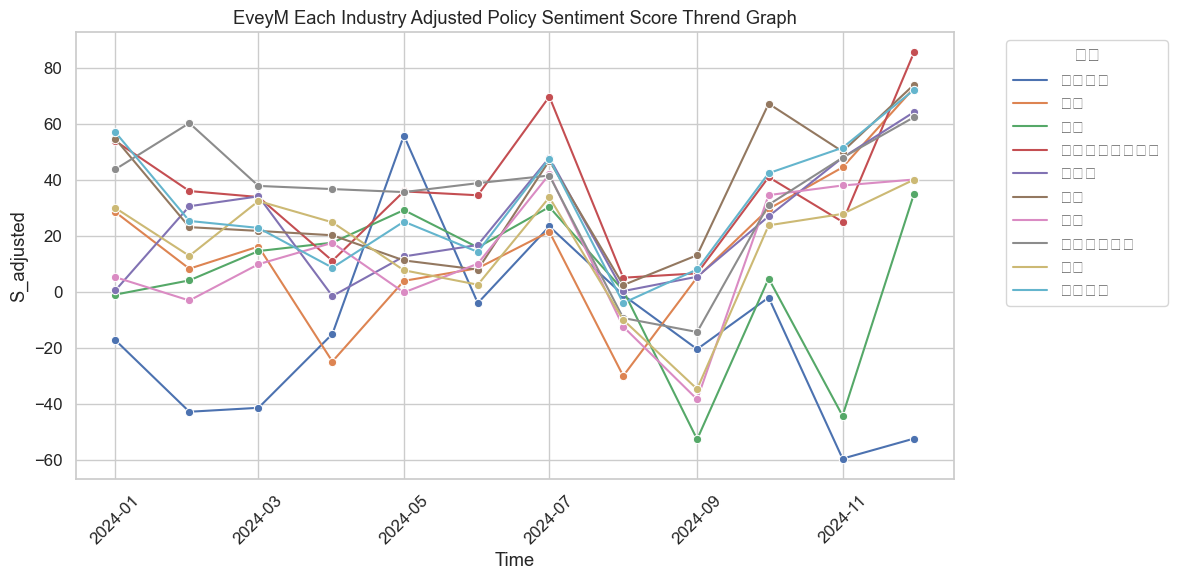

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


FREQ = 'M'  


T_map = {'国务院': 4.58, '国务院部门': 1.0}


df = pd.read_csv(r'C:\Users\wrz\Desktop\FYPProject\output.csv')
df['日期'] = pd.to_datetime(df['日期'])


sentiment_map = {'正面': 1, '中性': 0, '负面': -1}
df['sentiment_score'] = df['情感倾向'].map(sentiment_map)


df['T'] = df['机关层级'].map(T_map)


def assign_period(date, freq='M'):
    if freq == '2W':
        day = 1 if date.day <= 15 else 16
        return pd.Timestamp(year=date.year, month=date.month, day=day)
    elif freq == 'W':
        return date - pd.Timedelta(days=date.weekday())  
    elif freq == 'D':
        return date
    else:
        return pd.Timestamp(year=date.year, month=date.month, day=1)

df['period'] = df['日期'].apply(lambda x: assign_period(x, freq=FREQ))


def compute_adjusted_s(df_period):
    results = []
    grouped = df_period.groupby('影响行业')
    for industry, group in grouped:
        s = group['sentiment_score']
        mu, sigma = s.mean(), s.std()
        if sigma == 0 or np.isnan(sigma):
            s_adj = 0
        else:
            s_adj = ((s - mu) / sigma * group['T']).sum()
        results.append({'period': group['period'].iloc[0], 'industry': industry, 'S_adjusted': s_adj})
    return pd.DataFrame(results)

df_result = df.groupby('period').apply(compute_adjusted_s).reset_index(drop=True)


output_path = fr'C:\Users\wrz\Desktop\FYPProject\adjusted_policy_sentiment_score_{FREQ}.csv'
df_result.to_csv(output_path, index=False)
print(f"✅ 已导出：{output_path}")


sns.set(style="whitegrid", font_scale=1.1)

df_result['period'] = pd.to_datetime(df_result['period'])
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_result,
    x='period',
    y='S_adjusted',
    hue='industry',
    marker='o'
)

plt.title(f'Evey{FREQ} Each Industry Adjusted Policy Sentiment Score Thrend Graph')
plt.xlabel('Time')
plt.ylabel('S_adjusted')
plt.xticks(rotation=45)
plt.legend(title='行业', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


政策层级影响（平均涨跌幅 %）：
         ret_1d    ret_3d    ret_5d   ret_7d   ret_10d   ret_15d
机关层级                                                            
国务院    0.231475 -0.071393  0.083279  0.15459 -0.074262 -0.000410
国务院部门  0.036757 -0.059899  0.062095  0.11902 -0.034426 -0.056149


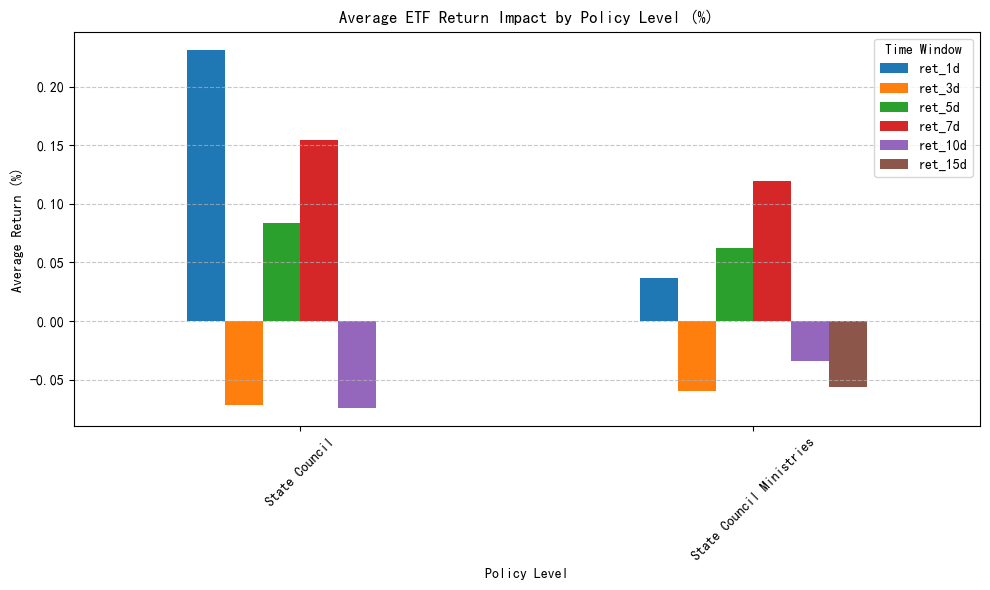

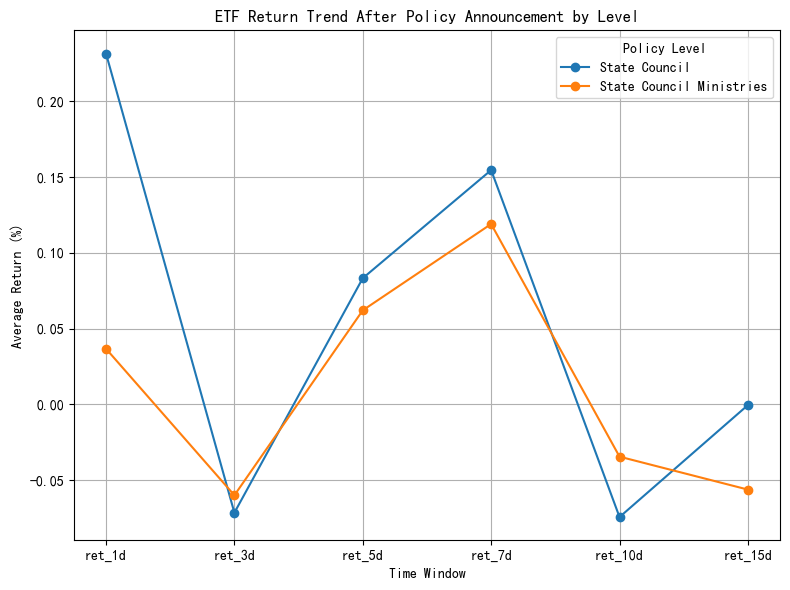

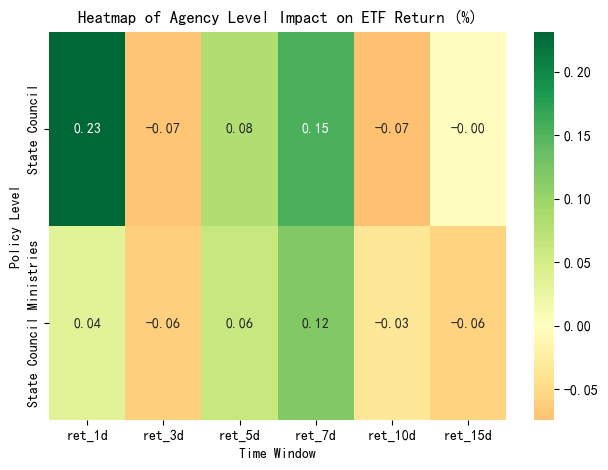

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

policy_df = pd.read_csv(r'C:\Users\wrz\Desktop\FYPProject\output.csv')
etf_df = pd.read_csv(r'C:\Users\wrz\Desktop\FYPProject\Data\159928.OF.csv')


policy_df['日期'] = pd.to_datetime(policy_df['日期'])
etf_df['日期'] = pd.to_datetime(etf_df['日期'])
etf_df = etf_df.sort_values('日期')


policy_df = policy_df[policy_df['影响行业'] == '消费']
policy_df = policy_df[['日期', '机关层级']].drop_duplicates()
etf_df = etf_df[['日期', '涨跌幅']]


results = []
for _, row in policy_df.iterrows():
    pub_date = row['日期']
    level = row['机关层级']
    future_returns = etf_df[etf_df['日期'] > pub_date].head(30) 

    result = {
        '日期': pub_date,
        '机关层级': level
    }
    
    for day in [1, 3, 5, 7, 10, 15]:
        key = f'ret_{day}d'
        result[key] = future_returns.iloc[day - 1]['涨跌幅'] if len(future_returns) >= day else None

    results.append(result)


result_df = pd.DataFrame(results)
cols = [f'ret_{d}d' for d in [1, 3, 5, 7, 10, 15]]
grouped = result_df.groupby('机关层级')[cols].mean()
grouped_percent = grouped * 100  


print("政策层级影响（平均涨跌幅 %）：")
print(grouped_percent)

level_mapping = {
    '国务院': 'State Council',
    '国务院部门': 'State Council Ministries'
}
grouped_percent.index = grouped_percent.index.map(level_mapping)


grouped_percent.plot(kind='bar', figsize=(10, 6))
plt.title('Average ETF Return Impact by Policy Level (%)')
plt.ylabel('Average Return (%)')
plt.xlabel('Policy Level')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend(title='Time Window')
plt.show()


grouped_percent.T.plot(marker='o', figsize=(8, 6))
plt.title('ETF Return Trend After Policy Announcement by Level')
plt.ylabel('Average Return (%)')
plt.xlabel('Time Window')
plt.grid(True)
plt.tight_layout()
plt.legend(title='Policy Level')
plt.show()


sns.heatmap(grouped_percent, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title('Heatmap of Agency Level Impact on ETF Return (%)')
plt.ylabel('Policy Level')
plt.xlabel('Time Window')
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd


df = pd.read_csv(r'C:\Users\wrz\Desktop\FYPProject\policy_level_impact.csv')


df_ret = df[['影响行业', '机关层级', 'ret_1d']]


pivot = df_ret.pivot(index='影响行业', columns='机关层级', values='ret_1d')
pivot = pivot.dropna() 
pivot['ratio'] = pivot['国务院'] / pivot['国务院部门']


T_ratio = pivot['ratio'].mean()
print(f" T 值：国务院 = {T_ratio:.2f}, 国务院部门 = 1.0")


 T 值：国务院 = 4.58, 国务院部门 = 1.0
